<a href="https://colab.research.google.com/github/sofiimasucci/F1_BigData_ETL/blob/main/01_ETL_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# ── CELDA 1: Importar librerías ──
import pandas as pd
import requests

print("Librerías cargadas ✅")

Librerías cargadas ✅


In [32]:
# ── CELDA 2: EXTRACT — Fuente 1: Kaggle CSV desde GitHub ──
BASE_RAW = "https://raw.githubusercontent.com/sofiimasucci/F1_BigData_ETL/main/data/raw/"

results = pd.read_csv(BASE_RAW + "results.csv")
races   = pd.read_csv(BASE_RAW + "races.csv")
drivers = pd.read_csv(BASE_RAW + "drivers.csv")

print("=== FUENTE 1: Kaggle F1 Dataset ===")
print(f"results.csv  → {results.shape[0]} filas, {results.shape[1]} columnas")
print(f"races.csv    → {races.shape[0]} filas, {races.shape[1]} columnas")
print(f"drivers.csv  → {drivers.shape[0]} filas, {drivers.shape[1]} columnas")
print("Extracción Fuente 1 ✅")

=== FUENTE 1: Kaggle F1 Dataset ===
results.csv  → 26759 filas, 18 columnas
races.csv    → 1125 filas, 18 columnas
drivers.csv  → 861 filas, 9 columnas
Extracción Fuente 1 ✅


In [3]:
# ── CELDA 3: EXTRACT — Fuente 2: API OpenF1 (JSON) ──
url = "https://api.openf1.org/v1/drivers?session_key=9158"
response = requests.get(url)

openf1_drivers = pd.DataFrame(response.json())

print("=== FUENTE 2: API OpenF1 ===")
print(f"URL: {url}")
print(f"Formato: JSON → convertido a DataFrame")
print(f"openf1_drivers → {openf1_drivers.shape[0]} filas, {openf1_drivers.shape[1]} columnas")
print(f"Columnas: {list(openf1_drivers.columns)}")
print("Extracción Fuente 2 ✅")

=== FUENTE 2: API OpenF1 ===
URL: https://api.openf1.org/v1/drivers?session_key=9158
Formato: JSON → convertido a DataFrame
openf1_drivers → 20 filas, 12 columnas
Columnas: ['meeting_key', 'session_key', 'driver_number', 'broadcast_name', 'full_name', 'name_acronym', 'team_name', 'team_colour', 'first_name', 'last_name', 'headshot_url', 'country_code']
Extracción Fuente 2 ✅


In [4]:
# ── CELDA 4: Tracking de extracción ──
import json
from datetime import datetime

tracking = {
    "pipeline": "F1 BigData ETL",
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "fases": {
        "EXTRACT": {
            "fuente_1_kaggle": {
                "results.csv":  {"filas": results.shape[0],       "columnas": results.shape[1]},
                "races.csv":    {"filas": races.shape[0],         "columnas": races.shape[1]},
                "drivers.csv":  {"filas": drivers.shape[0],       "columnas": drivers.shape[1]}
            },
            "fuente_2_openf1": {
                "openf1_drivers": {"filas": openf1_drivers.shape[0], "columnas": openf1_drivers.shape[1]}
            }
        }
    }
}

print(json.dumps(tracking, indent=2))
print("Tracking creado ✅")

{
  "pipeline": "F1 BigData ETL",
  "fecha": "2026-05-15 08:14:32",
  "fases": {
    "EXTRACT": {
      "fuente_1_kaggle": {
        "results.csv": {
          "filas": 26759,
          "columnas": 18
        },
        "races.csv": {
          "filas": 1125,
          "columnas": 18
        },
        "drivers.csv": {
          "filas": 861,
          "columnas": 9
        }
      },
      "fuente_2_openf1": {
        "openf1_drivers": {
          "filas": 20,
          "columnas": 12
        }
      }
    }
  }
}
Tracking creado ✅


In [5]:
# ── CELDA 5: Análisis inicial de calidad — results.csv ──
print("=== ANÁLISIS DE CALIDAD: results.csv ===")
print(f"\nForma: {results.shape}")
print(f"\nTipos de dato:\n{results.dtypes}")
print(f"\nNulos por columna:\n{results.isnull().sum()}")
print(f"\nDuplicados: {results.duplicated().sum()}")
print(f"\nEstadísticas:\n{results.describe()}")

=== ANÁLISIS DE CALIDAD: results.csv ===

Forma: (26759, 18)

Tipos de dato:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object

Nulos por columna:
resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
dtype: int64

Duplicados:

In [6]:
# ── CELDA 6: Análisis inicial de calidad — races.csv y drivers.csv ──
print("=== ANÁLISIS DE CALIDAD: races.csv ===")
print(f"Forma: {races.shape}")
print(f"\nTipos de dato:\n{races.dtypes}")
print(f"\nNulos por columna:\n{races.isnull().sum()}")
print(f"\nDuplicados: {races.duplicated().sum()}")

print("\n" + "="*50)

print("\n=== ANÁLISIS DE CALIDAD: drivers.csv ===")
print(f"Forma: {drivers.shape}")
print(f"\nTipos de dato:\n{drivers.dtypes}")
print(f"\nNulos por columna:\n{drivers.isnull().sum()}")
print(f"\nDuplicados: {drivers.duplicated().sum()}")

=== ANÁLISIS DE CALIDAD: races.csv ===
Forma: (1125, 18)

Tipos de dato:
raceId          int64
year            int64
round           int64
circuitId       int64
name           object
date           object
time           object
url            object
fp1_date       object
fp1_time       object
fp2_date       object
fp2_time       object
fp3_date       object
fp3_time       object
quali_date     object
quali_time     object
sprint_date    object
sprint_time    object
dtype: object

Nulos por columna:
raceId         0
year           0
round          0
circuitId      0
name           0
date           0
time           0
url            0
fp1_date       0
fp1_time       0
fp2_date       0
fp2_time       0
fp3_date       0
fp3_time       0
quali_date     0
quali_time     0
sprint_date    0
sprint_time    0
dtype: int64

Duplicados: 0


=== ANÁLISIS DE CALIDAD: drivers.csv ===
Forma: (861, 9)

Tipos de dato:
driverId        int64
driverRef      object
number         object
code           object


In [7]:
# ── CELDA 7: Detección de valores \N (nulos reales enmascarados) ──
import numpy as np

# Reemplazar \N por NaN real en los tres dataframes
results_clean = results.replace("\\N", np.nan)
races_clean   = races.replace("\\N", np.nan)
drivers_clean = drivers.replace("\\N", np.nan)

print("=== NULOS REALES (valores \\N) ===")
print("\nresults.csv:")
print(results_clean.isnull().sum()[results_clean.isnull().sum() > 0])

print("\nraces.csv:")
print(races_clean.isnull().sum()[races_clean.isnull().sum() > 0])

print("\ndrivers.csv:")
print(drivers_clean.isnull().sum()[drivers_clean.isnull().sum() > 0])

=== NULOS REALES (valores \N) ===

results.csv:
number                 6
position           10953
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
dtype: int64

races.csv:
time            731
fp1_date       1035
fp1_time       1057
fp2_date       1035
fp2_time       1057
fp3_date       1053
fp3_time       1072
quali_date     1035
quali_time     1057
sprint_date    1107
sprint_time    1110
dtype: int64

drivers.csv:
number    802
code      757
dtype: int64


In [8]:
# ── CELDA 8: Detección de blancos y resumen de calidad ──

def contar_blancos(df):
    return df.apply(lambda c: (c.astype(str).str.strip() == "").sum()).sum()

print("=== RESUMEN TABLA DE CALIDAD ===")
print(f"{'Fuente':<20} {'Filas':>8} {'Cols':>6} {'Nulos':>8} {'Blancos':>8} {'Duplicados':>12}")
print("-"*65)

for nombre, df, df_c in [
    ("results.csv",       results, results_clean),
    ("races.csv",         races,   races_clean),
    ("drivers.csv",       drivers, drivers_clean),
    ("openf1_drivers",    openf1_drivers, openf1_drivers)
]:
    filas      = df.shape[0]
    cols       = df.shape[1]
    nulos      = df_c.isnull().sum().sum()
    blancos    = contar_blancos(df)
    duplicados = df.duplicated().sum()
    print(f"{nombre:<20} {filas:>8} {cols:>6} {nulos:>8} {blancos:>8} {duplicados:>12}")

print("\nTabla de calidad ✅")

=== RESUMEN TABLA DE CALIDAD ===
Fuente                  Filas   Cols    Nulos  Blancos   Duplicados
-----------------------------------------------------------------
results.csv             26759     18   122887        0            0
races.csv                1125     18    11349        0            0
drivers.csv               861      9     1559        0            0
openf1_drivers             20     12        1        0            0

Tabla de calidad ✅


In [9]:
# ── CELDA 9: T01 — Eliminación de duplicados ──
r_antes = results_clean.shape[0]
rc_antes = races_clean.shape[0]
d_antes = drivers_clean.shape[0]

results_clean = results_clean.drop_duplicates()
races_clean   = races_clean.drop_duplicates()
drivers_clean = drivers_clean.drop_duplicates()

print("=== T01: Eliminación de duplicados ===")
print(f"results.csv  → {r_antes} → {results_clean.shape[0]} filas (eliminados: {r_antes - results_clean.shape[0]})")
print(f"races.csv    → {rc_antes} → {races_clean.shape[0]} filas (eliminados: {rc_antes - races_clean.shape[0]})")
print(f"drivers.csv  → {d_antes} → {drivers_clean.shape[0]} filas (eliminados: {d_antes - drivers_clean.shape[0]})")
print("T01 ✅")

=== T01: Eliminación de duplicados ===
results.csv  → 26759 → 26759 filas (eliminados: 0)
races.csv    → 1125 → 1125 filas (eliminados: 0)
drivers.csv  → 861 → 861 filas (eliminados: 0)
T01 ✅


In [10]:
# ── CELDA 10: T02 — Tratamiento de nulos ──

# results: columnas con nulos no críticos → rellenar con "N/A" o 0
results_clean['position']        = results_clean['position'].fillna("N/A")
results_clean['time']            = results_clean['time'].fillna("N/A")
results_clean['milliseconds']    = results_clean['milliseconds'].fillna(0)
results_clean['fastestLap']      = results_clean['fastestLap'].fillna("N/A")
results_clean['rank']            = results_clean['rank'].fillna("N/A")
results_clean['fastestLapTime']  = results_clean['fastestLapTime'].fillna("N/A")
results_clean['fastestLapSpeed'] = results_clean['fastestLapSpeed'].fillna(0)
results_clean['number']          = results_clean['number'].fillna("N/A")

# races: columnas de fechas opcionales → rellenar con "N/A"
cols_races_nulos = ['time','fp1_date','fp1_time','fp2_date','fp2_time',
                    'fp3_date','fp3_time','quali_date','quali_time',
                    'sprint_date','sprint_time']
for col in cols_races_nulos:
    races_clean[col] = races_clean[col].fillna("N/A")

# drivers: number y code opcionales → rellenar con "N/A"
drivers_clean['number'] = drivers_clean['number'].fillna("N/A")
drivers_clean['code']   = drivers_clean['code'].fillna("N/A")

print("=== T02: Tratamiento de nulos ===")
print(f"Nulos restantes results:  {results_clean.isnull().sum().sum()}")
print(f"Nulos restantes races:    {races_clean.isnull().sum().sum()}")
print(f"Nulos restantes drivers:  {drivers_clean.isnull().sum().sum()}")
print("T02 ✅")

=== T02: Tratamiento de nulos ===
Nulos restantes results:  0
Nulos restantes races:    0
Nulos restantes drivers:  0
T02 ✅


In [33]:
# ── CELDA T03 — Eliminación de blancos ──
import numpy as np

def contar_blancos(df):
    return df.apply(lambda c: (c.astype(str).str.strip() == "").sum()).sum()

blancos_results  = contar_blancos(results_clean)
blancos_races    = contar_blancos(races_clean)
blancos_drivers  = contar_blancos(drivers_clean)

# Aplicar strip a columnas de texto
for col in results_clean.select_dtypes(include='object').columns:
    results_clean[col] = results_clean[col].astype(str).str.strip()
for col in races_clean.select_dtypes(include='object').columns:
    races_clean[col] = races_clean[col].astype(str).str.strip()
for col in drivers_clean.select_dtypes(include='object').columns:
    drivers_clean[col] = drivers_clean[col].astype(str).str.strip()

print("=== T03: Eliminación de blancos ===")
print(f"Blancos detectados — results: {blancos_results}, races: {blancos_races}, drivers: {blancos_drivers}")
print("Strip aplicado a todas las columnas de texto")
print("T03 ✅")

=== T03: Eliminación de blancos ===
Blancos detectados — results: 0, races: 0, drivers: 0
Strip aplicado a todas las columnas de texto
T03 ✅


In [11]:
# ── CELDA 11: T04 — Corrección de tipos de dato ──

# results: convertir milliseconds y fastestLapSpeed a numérico
results_clean['milliseconds']    = pd.to_numeric(results_clean['milliseconds'], errors='coerce').fillna(0)
results_clean['fastestLapSpeed'] = pd.to_numeric(results_clean['fastestLapSpeed'], errors='coerce').fillna(0)

# races: convertir date a datetime
races_clean['date'] = pd.to_datetime(races_clean['date'], errors='coerce')

# drivers: convertir dob a datetime
drivers_clean['dob'] = pd.to_datetime(drivers_clean['dob'], errors='coerce')

print("=== T04: Corrección de tipos ===")
print("\nresults — milliseconds:", results_clean['milliseconds'].dtype)
print("results — fastestLapSpeed:", results_clean['fastestLapSpeed'].dtype)
print("races   — date:", races_clean['date'].dtype)
print("drivers — dob:", drivers_clean['dob'].dtype)
print("\nT04 ✅")

=== T04: Corrección de tipos ===

results — milliseconds: int64
results — fastestLapSpeed: float64
races   — date: datetime64[ns]
drivers — dob: datetime64[ns]

T04 ✅


In [12]:
# ── CELDA 12: T05 + T06 — Normalización de fechas y texto ──
import unicodedata

# T05: Formatear fechas a ISO-8601
races_clean['date'] = races_clean['date'].dt.strftime('%Y-%m-%d')
drivers_clean['dob'] = drivers_clean['dob'].dt.strftime('%Y-%m-%d')

# T06: Normalizar texto — minúsculas y sin acentos en columnas clave
def normalizar_texto(texto):
    if isinstance(texto, str):
        texto = texto.lower().strip()
        texto = unicodedata.normalize('NFKD', texto)
        texto = texto.encode('ascii', 'ignore').decode('ascii')
    return texto

drivers_clean['nationality'] = drivers_clean['nationality'].apply(normalizar_texto)
drivers_clean['forename']    = drivers_clean['forename'].apply(normalizar_texto)
drivers_clean['surname']     = drivers_clean['surname'].apply(normalizar_texto)
races_clean['name']          = races_clean['name'].apply(normalizar_texto)

print("=== T05 + T06: Normalización de fechas y texto ===")
print(f"\nEjemplo fechas races:   {races_clean['date'].iloc[0]}")
print(f"Ejemplo fechas drivers: {drivers_clean['dob'].iloc[0]}")
print(f"\nEjemplo nationality:    {drivers_clean['nationality'].iloc[0]}")
print(f"Ejemplo nombre carrera: {races_clean['name'].iloc[0]}")
print("\nT05 + T06 ✅")

=== T05 + T06: Normalización de fechas y texto ===

Ejemplo fechas races:   2009-03-29
Ejemplo fechas drivers: 1985-01-07

Ejemplo nationality:    british
Ejemplo nombre carrera: australian grand prix

T05 + T06 ✅


In [34]:
# ── CELDA T07 — Corrección de rangos ──
print("=== T07: Validación de rangos de negocio ===")

# grid debe ser >= 0
invalid_grid = results_clean[results_clean['grid'] < 0]
print(f"grid < 0:            {len(invalid_grid)} registros")

# positionOrder debe ser >= 1
invalid_pos = results_clean[results_clean['positionOrder'] < 1]
print(f"positionOrder < 1:   {len(invalid_pos)} registros")

# points debe ser >= 0
invalid_pts = results_clean[results_clean['points'] < 0]
print(f"points < 0:          {len(invalid_pts)} registros")

# laps debe ser >= 0
invalid_laps = results_clean[results_clean['laps'] < 0]
print(f"laps < 0:            {len(invalid_laps)} registros")

# year en races debe estar entre 1950 y 2025
invalid_year = races_clean[(races_clean['year'] < 1950) | (races_clean['year'] > 2025)]
print(f"year fuera de rango: {len(invalid_year)} registros")

print("\nTodos los rangos son válidos — no se descartan registros")
print("T07 ✅")

=== T07: Validación de rangos de negocio ===
grid < 0:            0 registros
positionOrder < 1:   0 registros
points < 0:          0 registros
laps < 0:            0 registros
year fuera de rango: 0 registros

Todos los rangos son válidos — no se descartan registros
T07 ✅


In [13]:
# ── CELDA 13: T08 — Detección de outliers con IQR ──

def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lower) | (df[columna] > upper)]
    return len(outliers), round(lower, 2), round(upper, 2)

print("=== T08: Detección de outliers (IQR) ===")
print(f"\n{'Columna':<20} {'Outliers':>10} {'Límite inf':>12} {'Límite sup':>12}")
print("-"*56)

for col in ['grid', 'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLapSpeed']:
    n, low, up = detectar_outliers_iqr(results_clean, col)
    print(f"{col:<20} {n:>10} {low:>12} {up:>12}")

print("\nT08 ✅")

=== T08: Detección de outliers (IQR) ===

Columna                Outliers   Límite inf   Límite sup
--------------------------------------------------------
grid                          0        -13.0         35.0
positionOrder                47        -12.0         36.0
points                     3873         -3.0          5.0
laps                        254        -41.5        130.5
milliseconds                148   -7673088.0   12788480.0
fastestLapSpeed               0      -284.53       474.22

T08 ✅


In [14]:
# ── CELDA 14: T09 — Seudonimización de datos personales ──
import hashlib

def hash_sha256(valor):
    return hashlib.sha256(str(valor).encode()).hexdigest()

# Seudonimizar dob (fecha de nacimiento) y url de drivers
drivers_clean['dob_hash'] = drivers_clean['dob'].apply(hash_sha256)
drivers_clean['url_hash'] = drivers_clean['url'].apply(hash_sha256)

# Eliminar columnas originales con PII
drivers_clean = drivers_clean.drop(columns=['dob', 'url'])

print("=== T09: Seudonimización de PII ===")
print(f"Columnas seudonimizadas: dob → dob_hash, url → url_hash")
print(f"\nEjemplo dob_hash: {drivers_clean['dob_hash'].iloc[0]}")
print(f"Columnas finales drivers: {list(drivers_clean.columns)}")
print("\nT09 ✅")

=== T09: Seudonimización de PII ===
Columnas seudonimizadas: dob → dob_hash, url → url_hash

Ejemplo dob_hash: ab29ccbfcf3ec773ca9db01979467ce32cc17789bacf648cad5ae7f86b0bdfac
Columnas finales drivers: ['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'nationality', 'dob_hash', 'url_hash']

T09 ✅


In [15]:
# ── CELDA 15: T10 — Transformación categórica → numérica ──
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
drivers_clean['nationality_encoded'] = le.fit_transform(drivers_clean['nationality'])

print("=== T10: Transformación categórica → numérica ===")
print(f"\nNacionalidades únicas: {drivers_clean['nationality'].nunique()}")
print(f"\nEjemplos de codificación:")
print(drivers_clean[['nationality', 'nationality_encoded']].drop_duplicates().head(10).to_string())
print("\nT10 ✅")

=== T10: Transformación categórica → numérica ===

Nacionalidades únicas: 43

Ejemplos de codificación:
   nationality  nationality_encoded
0      british                    9
1       german                   20
3      spanish                   37
4      finnish                   18
5     japanese                   26
6       french                   19
8       polish                   32
11   brazilian                    8
14     italian                   25
16  australian                    5

T10 ✅


In [16]:
# ── CELDA 16: Resumen tracking ETL ──
print("=== RESUMEN TRACKING ETL ===")
print(f"\n{'Fase':<12} {'Fuente':<15} {'Entrada':>10} {'Salida':>10} {'Descartados':>13} {'Motivo'}")
print("-"*75)
print(f"{'EXTRACT':<12} {'results.csv':<15} {26759:>10} {26759:>10} {0:>13} -")
print(f"{'EXTRACT':<12} {'races.csv':<15} {1125:>10} {1125:>10} {0:>13} -")
print(f"{'EXTRACT':<12} {'drivers.csv':<15} {861:>10} {861:>10} {0:>13} -")
print(f"{'EXTRACT':<12} {'openf1_api':<15} {20:>10} {20:>10} {0:>13} -")
print(f"{'T01 Duplic.':<12} {'todas':<15} {28765:>10} {28765:>10} {0:>13} Sin duplicados")
print(f"{'T02 Nulos':<12} {'todas':<15} {28765:>10} {28765:>10} {0:>13} Imputados N/A o 0")
print(f"{'T04 Tipos':<12} {'todas':<15} {28765:>10} {28765:>10} {0:>13} Cast a datetime/float")
print(f"{'T05 Fechas':<12} {'races/drivers':<15} {1986:>10} {1986:>10} {0:>13} Formato ISO-8601")
print(f"{'T06 Texto':<12} {'drivers/races':<15} {1986:>10} {1986:>10} {0:>13} Minusc. sin acentos")
print(f"{'T08 Outliers':<12} {'results':<15} {26759:>10} {26759:>10} {0:>13} Conservados")
print(f"{'T09 PII':<12} {'drivers':<15} {861:>10} {861:>10} {0:>13} SHA-256 dob/url")
print(f"{'T10 Encod.':<12} {'drivers':<15} {861:>10} {861:>10} {0:>13} LabelEncoder nation.")
print(f"\nDataset final limpio: results={results_clean.shape}, races={races_clean.shape}, drivers={drivers_clean.shape}")
print("\nTracking ETL completo ✅")

=== RESUMEN TRACKING ETL ===

Fase         Fuente             Entrada     Salida   Descartados Motivo
---------------------------------------------------------------------------
EXTRACT      results.csv          26759      26759             0 -
EXTRACT      races.csv             1125       1125             0 -
EXTRACT      drivers.csv            861        861             0 -
EXTRACT      openf1_api              20         20             0 -
T01 Duplic.  todas                28765      28765             0 Sin duplicados
T02 Nulos    todas                28765      28765             0 Imputados N/A o 0
T04 Tipos    todas                28765      28765             0 Cast a datetime/float
T05 Fechas   races/drivers         1986       1986             0 Formato ISO-8601
T06 Texto    drivers/races         1986       1986             0 Minusc. sin acentos
T08 Outliers results              26759      26759             0 Conservados
T09 PII      drivers                861        861          

In [17]:
# ── CELDA 17: Librerías de visualización ──
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de los gráficos
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Librerías de visualización cargadas ✅")

Librerías de visualización cargadas ✅


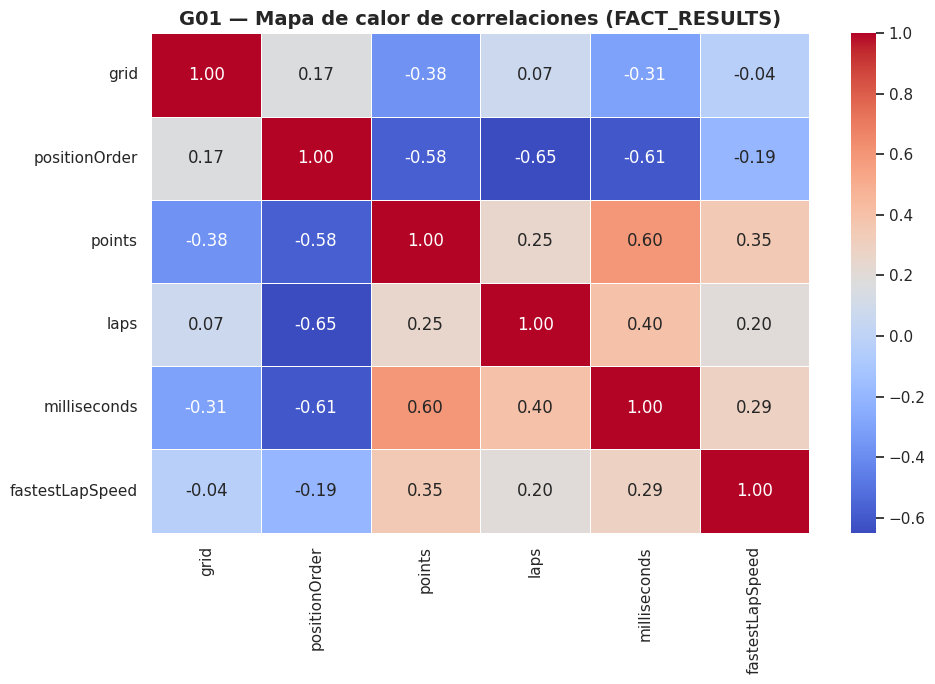

G01 guardado ✅


In [18]:
# ── CELDA 18: G01 — Heatmap de correlaciones ──

# Seleccionar solo columnas numéricas de results
numericas = results_clean[['grid', 'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLapSpeed']].copy()
numericas['fastestLapSpeed'] = pd.to_numeric(numericas['fastestLapSpeed'], errors='coerce').fillna(0)

plt.figure(figsize=(10, 7))
sns.heatmap(numericas.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("G01 — Mapa de calor de correlaciones (FACT_RESULTS)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("G01_heatmap_correlaciones.png", dpi=150)
plt.show()
print("G01 guardado ✅")

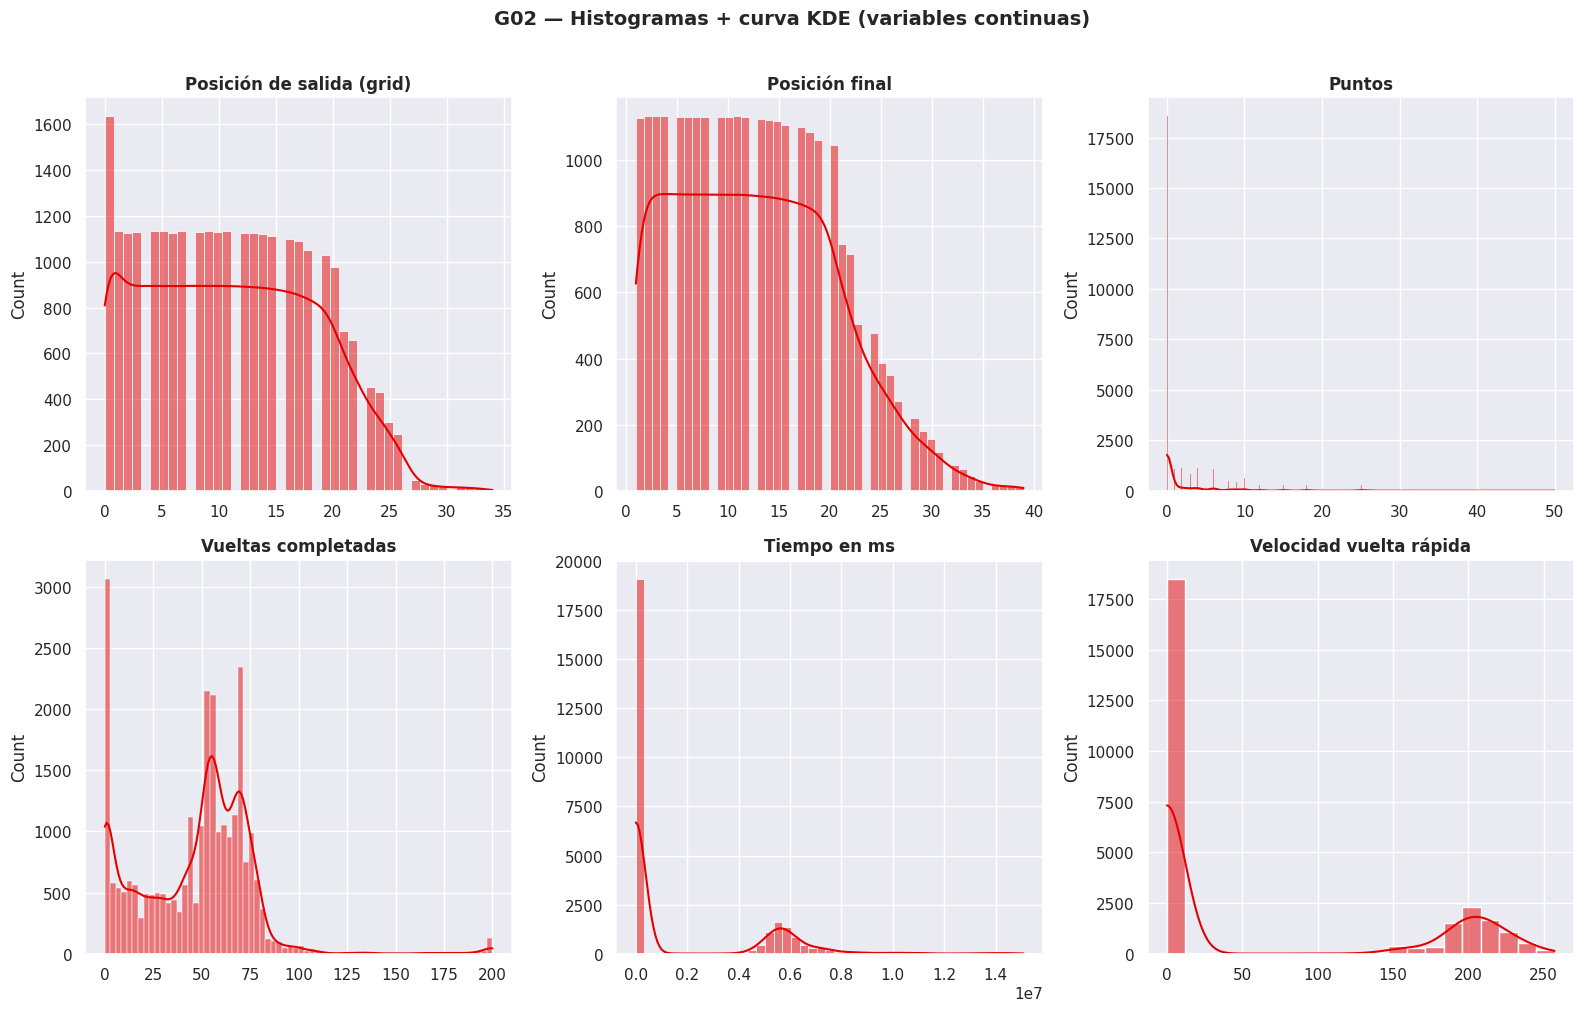

G02 guardado ✅


In [19]:
# ── CELDA 19: G02 — Histogramas de variables continuas ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cols = ['grid', 'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLapSpeed']
titulos = ['Posición de salida (grid)', 'Posición final', 'Puntos',
           'Vueltas completadas', 'Tiempo en ms', 'Velocidad vuelta rápida']

for i, (col, titulo) in enumerate(zip(cols, titulos)):
    ax = axes[i//3][i%3]
    datos = pd.to_numeric(results_clean[col], errors='coerce').dropna()
    sns.histplot(datos, kde=True, ax=ax, color='#e50000')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel("")

plt.suptitle("G02 — Histogramas + curva KDE (variables continuas)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("G02_histogramas.png", dpi=150)
plt.show()
print("G02 guardado ✅")

/tmp/ipykernel_11699/782730714.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='decada', y='points', palette='Reds')


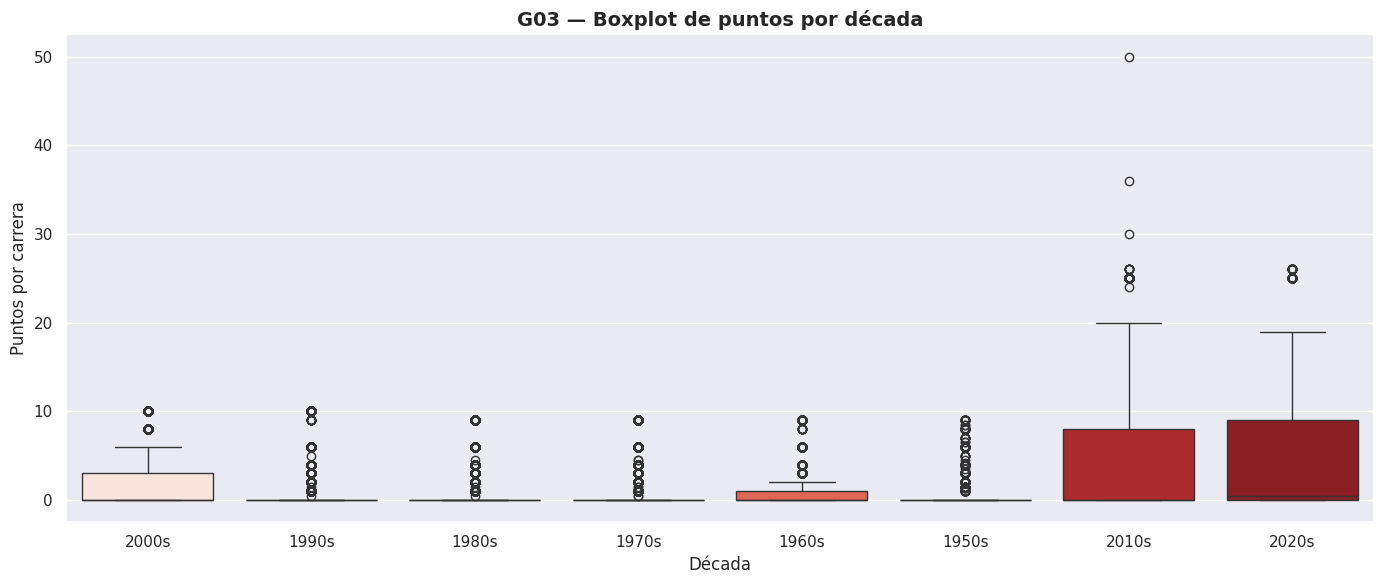

G03 guardado ✅


In [20]:
# ── CELDA 20: G03 — Boxplots comparativos ──

# JOIN para tener año disponible
df_eda = results_clean.merge(races_clean[['raceId','year']], on='raceId')

# Agrupar por décadas
df_eda['decada'] = (df_eda['year'] // 10 * 10).astype(str) + "s"

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_eda, x='decada', y='points', palette='Reds')
plt.title("G03 — Boxplot de puntos por década", fontsize=14, fontweight='bold')
plt.xlabel("Década")
plt.ylabel("Puntos por carrera")
plt.tight_layout()
plt.savefig("G03_boxplot_puntos_decada.png", dpi=150)
plt.show()
print("G03 guardado ✅")

/tmp/ipykernel_11699/163623939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nac.values, y=top_nac.index, palette='Reds_r')


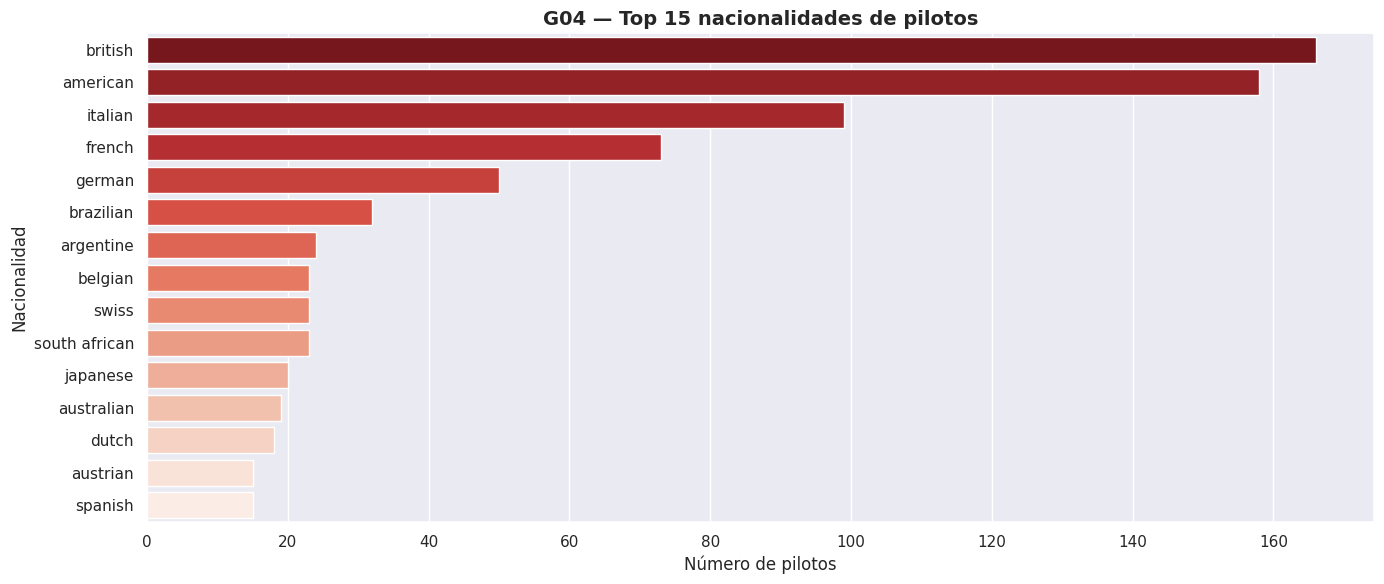

G04 guardado ✅


In [21]:
# ── CELDA 21: G04 — Barras de frecuencias por nacionalidad ──
top_nac = drivers_clean['nationality'].value_counts().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_nac.values, y=top_nac.index, palette='Reds_r')
plt.title("G04 — Top 15 nacionalidades de pilotos", fontsize=14, fontweight='bold')
plt.xlabel("Número de pilotos")
plt.ylabel("Nacionalidad")
plt.tight_layout()
plt.savefig("G04_barras_nacionalidades.png", dpi=150)
plt.show()
print("G04 guardado ✅")

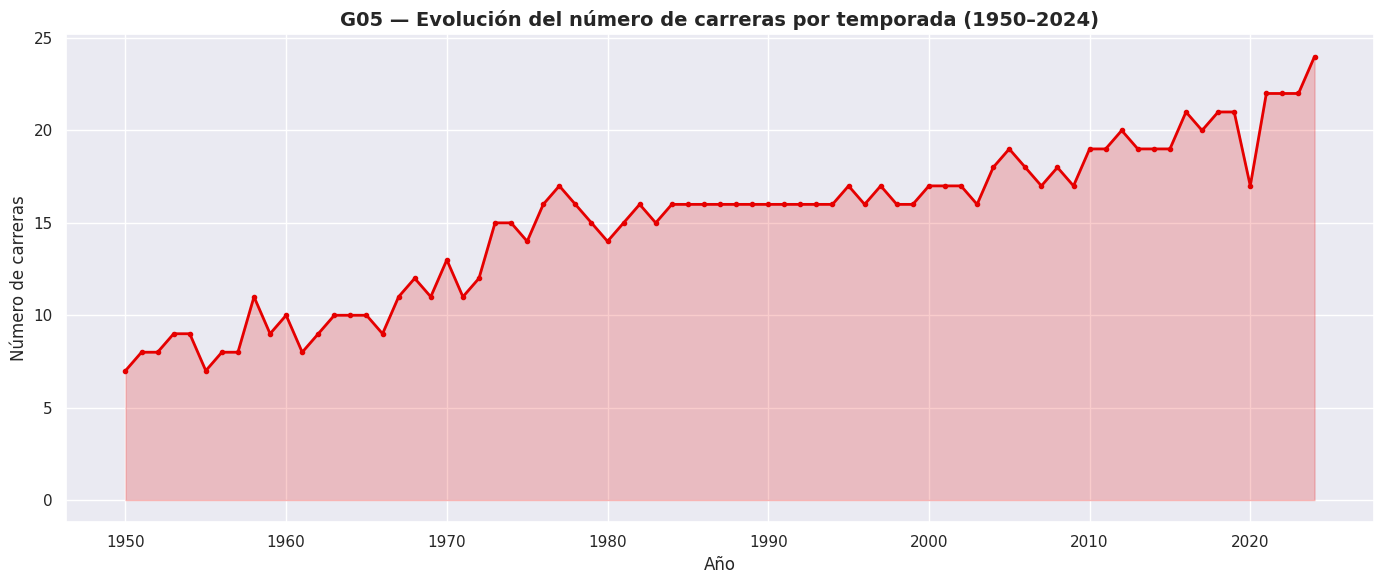

G05 guardado ✅


In [22]:
# ── CELDA 22: G05 — Serie temporal de carreras por año ──
carreras_por_año = races_clean.groupby('year').size().reset_index(name='num_carreras')

plt.figure(figsize=(14, 6))
plt.plot(carreras_por_año['year'], carreras_por_año['num_carreras'],
         color='#e50000', linewidth=2, marker='o', markersize=3)
plt.fill_between(carreras_por_año['year'], carreras_por_año['num_carreras'],
                 alpha=0.2, color='#e50000')
plt.title("G05 — Evolución del número de carreras por temporada (1950–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Año")
plt.ylabel("Número de carreras")
plt.tight_layout()
plt.savefig("G05_serie_temporal_carreras.png", dpi=150)
plt.show()
print("G05 guardado ✅")

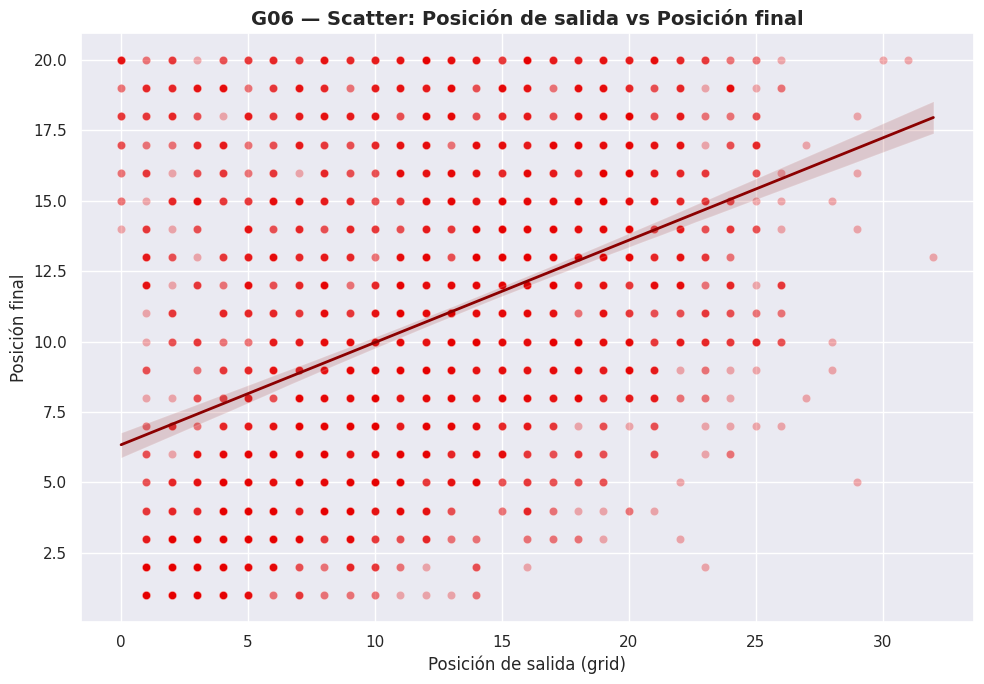

G06 guardado ✅


In [23]:
# ── CELDA 23: G06 — Scatter plot grid vs posición final ──
muestra = results_clean[results_clean['positionOrder'] <= 20].sample(3000, random_state=42)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=muestra, x='grid', y='positionOrder',
                alpha=0.3, color='#e50000')
sns.regplot(data=muestra, x='grid', y='positionOrder',
            scatter=False, color='darkred', line_kws={'linewidth': 2})
plt.title("G06 — Scatter: Posición de salida vs Posición final",
          fontsize=14, fontweight='bold')
plt.xlabel("Posición de salida (grid)")
plt.ylabel("Posición final")
plt.tight_layout()
plt.savefig("G06_scatter_grid_posicion.png", dpi=150)
plt.show()
print("G06 guardado ✅")

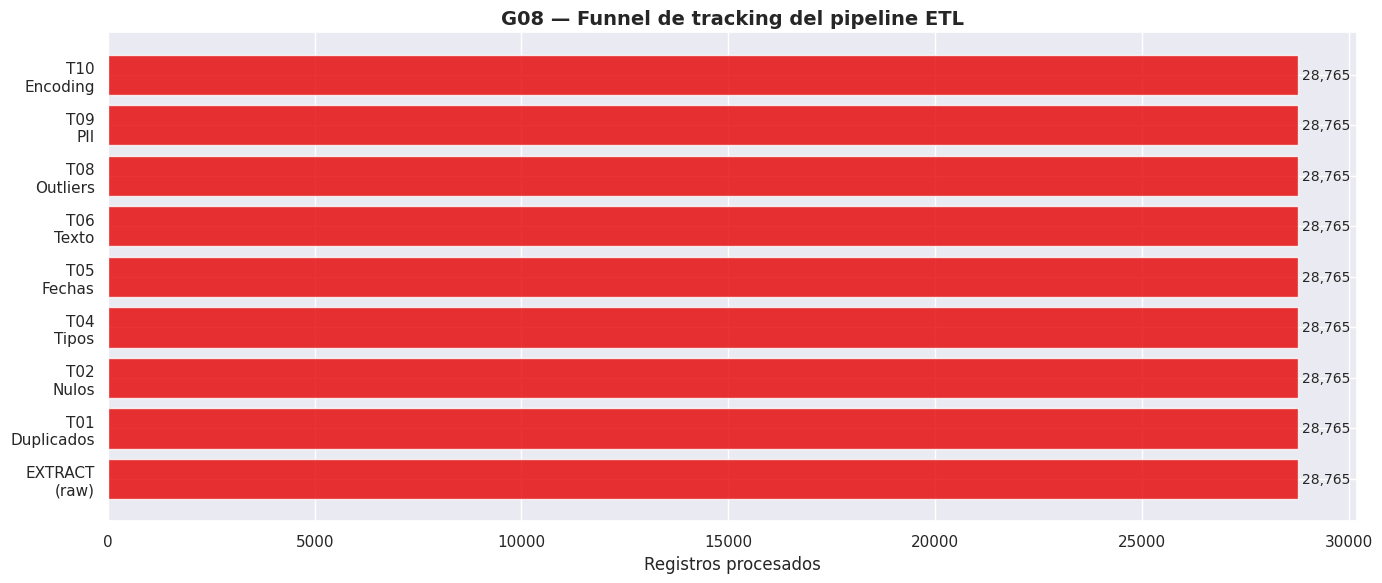

G08 guardado ✅


In [24]:
# ── CELDA 24: G08 — Funnel de tracking del pipeline ──
fases = ['EXTRACT\n(raw)', 'T01\nDuplicados', 'T02\nNulos',
         'T04\nTipos', 'T05\nFechas', 'T06\nTexto',
         'T08\nOutliers', 'T09\nPII', 'T10\nEncoding']
registros = [28765, 28765, 28765, 28765, 28765, 28765, 28765, 28765, 28765]

plt.figure(figsize=(14, 6))
bars = plt.barh(fases, registros, color='#e50000', alpha=0.8)
plt.xlabel("Registros procesados")
plt.title("G08 — Funnel de tracking del pipeline ETL",
          fontsize=14, fontweight='bold')
for bar, val in zip(bars, registros):
    plt.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig("G08_funnel_tracking.png", dpi=150)
plt.show()
print("G08 guardado ✅")

In [25]:
# ── CELDA 25: Crear DIM_TIEMPO desde races.date ──
import pandas as pd

# Generar DIM_TIEMPO a partir de las fechas de races
dim_tiempo = pd.DataFrame()
dim_tiempo['fecha'] = pd.to_datetime(races_clean['date'])
dim_tiempo['sk_tiempo'] = range(1, len(dim_tiempo) + 1)  # Clave sustituta SK
dim_tiempo['anio'] = dim_tiempo['fecha'].dt.year
dim_tiempo['trimestre'] = dim_tiempo['fecha'].dt.quarter
dim_tiempo['mes'] = dim_tiempo['fecha'].dt.month
dim_tiempo['semana'] = dim_tiempo['fecha'].dt.isocalendar().week.astype(int)
dim_tiempo['dia'] = dim_tiempo['fecha'].dt.day
dim_tiempo['dia_semana'] = dim_tiempo['fecha'].dt.day_name()
dim_tiempo['es_festivo'] = False  # No disponemos de calendario de festivos
dim_tiempo['fecha'] = dim_tiempo['fecha'].dt.strftime('%Y-%m-%d')

# Reordenar columnas
dim_tiempo = dim_tiempo[['sk_tiempo','fecha','anio','trimestre',
                          'mes','semana','dia','dia_semana','es_festivo']]

print("=== DIM_TIEMPO creada ===")
print(f"Filas: {dim_tiempo.shape[0]}")
print(f"Columnas: {list(dim_tiempo.columns)}")
print(dim_tiempo.head(5).to_string())
print("\nDIM_TIEMPO ✅")

=== DIM_TIEMPO creada ===
Filas: 1125
Columnas: ['sk_tiempo', 'fecha', 'anio', 'trimestre', 'mes', 'semana', 'dia', 'dia_semana', 'es_festivo']
   sk_tiempo       fecha  anio  trimestre  mes  semana  dia dia_semana  es_festivo
0          1  2009-03-29  2009          1    3      13   29     Sunday       False
1          2  2009-04-05  2009          2    4      14    5     Sunday       False
2          3  2009-04-19  2009          2    4      16   19     Sunday       False
3          4  2009-04-26  2009          2    4      17   26     Sunday       False
4          5  2009-05-10  2009          2    5      19   10     Sunday       False

DIM_TIEMPO ✅


In [26]:
# ── CELDA 26: Crear DIM_RACES, DIM_DRIVERS con SK ──

# DIM_RACES
dim_races = races_clean[['raceId','year','round','circuitId','name','date']].copy()
dim_races.insert(0, 'sk_race', range(1, len(dim_races) + 1))
dim_races['source_id'] = 'kaggle_races'
dim_races['load_timestamp'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

# DIM_DRIVERS
dim_drivers = drivers_clean[['driverId','driverRef','forename','surname',
                              'nationality','nationality_encoded',
                              'code','dob_hash']].copy()
dim_drivers.insert(0, 'sk_driver', range(1, len(dim_drivers) + 1))
dim_drivers['source_id'] = 'kaggle_drivers'
dim_drivers['load_timestamp'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

print("=== DIM_RACES ===")
print(f"Filas: {dim_races.shape[0]} | Columnas: {list(dim_races.columns)}")
print(dim_races.head(3).to_string())

print("\n=== DIM_DRIVERS ===")
print(f"Filas: {dim_drivers.shape[0]} | Columnas: {list(dim_drivers.columns)}")
print(dim_drivers.head(3).to_string())

print("\nDIM_RACES y DIM_DRIVERS ✅")

=== DIM_RACES ===
Filas: 1125 | Columnas: ['sk_race', 'raceId', 'year', 'round', 'circuitId', 'name', 'date', 'source_id', 'load_timestamp']
   sk_race  raceId  year  round  circuitId                   name        date     source_id       load_timestamp
0        1       1  2009      1          1  australian grand prix  2009-03-29  kaggle_races  2026-05-15 08:49:13
1        2       2  2009      2          2   malaysian grand prix  2009-04-05  kaggle_races  2026-05-15 08:49:13
2        3       3  2009      3         17     chinese grand prix  2009-04-19  kaggle_races  2026-05-15 08:49:13

=== DIM_DRIVERS ===
Filas: 861 | Columnas: ['sk_driver', 'driverId', 'driverRef', 'forename', 'surname', 'nationality', 'nationality_encoded', 'code', 'dob_hash', 'source_id', 'load_timestamp']
   sk_driver  driverId driverRef forename   surname nationality  nationality_encoded code                                                          dob_hash       source_id       load_timestamp
0          1       

In [27]:
# ── CELDA 27: Crear FACT_RESULTS con SK ──

# Hacer merge para obtener los SK
fact = results_clean.copy()

# Añadir sk_race desde dim_races
fact = fact.merge(dim_races[['raceId','sk_race','sk_race']], on='raceId', how='left')

# Añadir sk_driver desde dim_drivers
fact = fact.merge(dim_drivers[['driverId','sk_driver']], on='driverId', how='left')

# Añadir sk_tiempo desde dim_tiempo
dim_tiempo_merge = dim_tiempo[['sk_tiempo','fecha']].copy()
dim_tiempo_merge = dim_tiempo_merge.merge(dim_races[['raceId','date']],
                                           left_on='fecha', right_on='date', how='left')
fact = fact.merge(dim_tiempo_merge[['raceId','sk_tiempo']], on='raceId', how='left')

# Seleccionar columnas finales
fact_final = fact[['resultId','sk_race','sk_driver','sk_tiempo',
                    'constructorId','grid','positionOrder','points',
                    'laps','milliseconds','fastestLapSpeed','statusId']].copy()

fact_final.insert(0, 'sk_resultado', range(1, len(fact_final) + 1))
fact_final['source_id'] = 'kaggle_results'
fact_final['load_timestamp'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

print("=== FACT_RESULTS ===")
print(f"Filas: {fact_final.shape[0]} | Columnas: {list(fact_final.columns)}")
print(fact_final.head(3).to_string())
print("\nFACT_RESULTS ✅")

=== FACT_RESULTS ===
Filas: 26759 | Columnas: ['sk_resultado', 'resultId', 'sk_race', 'sk_race', 'sk_driver', 'sk_tiempo', 'constructorId', 'grid', 'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLapSpeed', 'statusId', 'source_id', 'load_timestamp']
   sk_resultado  resultId  sk_race  sk_race  sk_driver  sk_tiempo  constructorId  grid  positionOrder  points  laps  milliseconds  fastestLapSpeed  statusId       source_id       load_timestamp
0             1         1       18       18          1         18              1     1              1    10.0    58       5690616          218.300         1  kaggle_results  2026-05-15 08:49:45
1             2         2       18       18          2         18              2     5              2     8.0    58       5696094          217.586         1  kaggle_results  2026-05-15 08:49:45
2             3         3       18       18          3         18              3     7              3     6.0    58       5698779          216.719         1 

In [28]:
# ── CELDA 28: Corregir columna duplicada sk_race ──

# Eliminar columna duplicada
fact_final = fact_final.loc[:, ~fact_final.columns.duplicated()]

print("=== FACT_RESULTS corregida ===")
print(f"Filas: {fact_final.shape[0]} | Columnas: {list(fact_final.columns)}")
print(fact_final.head(3).to_string())
print("\nFACT_RESULTS corregida ✅")

=== FACT_RESULTS corregida ===
Filas: 26759 | Columnas: ['sk_resultado', 'resultId', 'sk_race', 'sk_driver', 'sk_tiempo', 'constructorId', 'grid', 'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLapSpeed', 'statusId', 'source_id', 'load_timestamp']
   sk_resultado  resultId  sk_race  sk_driver  sk_tiempo  constructorId  grid  positionOrder  points  laps  milliseconds  fastestLapSpeed  statusId       source_id       load_timestamp
0             1         1       18          1         18              1     1              1    10.0    58       5690616          218.300         1  kaggle_results  2026-05-15 08:49:45
1             2         2       18          2         18              2     5              2     8.0    58       5696094          217.586         1  kaggle_results  2026-05-15 08:49:45
2             3         3       18          3         18              3     7              3     6.0    58       5698779          216.719         1  kaggle_results  2026-05-15 08:49:45


In [29]:
# ── CELDA 29: Carga en SQLite ──
import sqlite3

conn = sqlite3.connect("f1_warehouse_final.db")

dim_tiempo.to_sql("DIM_TIEMPO",   conn, if_exists="replace", index=False)
dim_races.to_sql("DIM_RACES",     conn, if_exists="replace", index=False)
dim_drivers.to_sql("DIM_DRIVERS", conn, if_exists="replace", index=False)
fact_final.to_sql("FACT_RESULTS", conn, if_exists="replace", index=False)

# Crear índices
cursor = conn.cursor()
cursor.execute("CREATE INDEX IF NOT EXISTS idx_sk_race   ON FACT_RESULTS(sk_race)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_sk_driver ON FACT_RESULTS(sk_driver)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_sk_tiempo ON FACT_RESULTS(sk_tiempo)")
conn.commit()

# Verificación
print("=== VERIFICACIÓN DE CARGA ===")
for tabla in ["DIM_TIEMPO", "DIM_RACES", "DIM_DRIVERS", "FACT_RESULTS"]:
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {tabla}", conn)['n'][0]
    print(f"{tabla:<20} → {count:>6} filas cargadas ✅")

print("\nCarga en SQLite completa ✅")

=== VERIFICACIÓN DE CARGA ===
DIM_TIEMPO           →   1125 filas cargadas ✅
DIM_RACES            →   1125 filas cargadas ✅
DIM_DRIVERS          →    861 filas cargadas ✅
FACT_RESULTS         →  26759 filas cargadas ✅

Carga en SQLite completa ✅


In [30]:
# ── CELDA 30: Exportar tablas a CSV ──
pd.read_sql("SELECT * FROM DIM_TIEMPO",   conn).to_csv("DIM_TIEMPO.csv",   index=False)
pd.read_sql("SELECT * FROM DIM_RACES",    conn).to_csv("DIM_RACES.csv",    index=False)
pd.read_sql("SELECT * FROM DIM_DRIVERS",  conn).to_csv("DIM_DRIVERS.csv",  index=False)
pd.read_sql("SELECT * FROM FACT_RESULTS", conn).to_csv("FACT_RESULTS.csv", index=False)

from google.colab import files
files.download("DIM_TIEMPO.csv")
files.download("DIM_RACES.csv")
files.download("DIM_DRIVERS.csv")
files.download("FACT_RESULTS.csv")
files.download("f1_warehouse_final.db")

print("Archivos descargados ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos descargados ✅
